In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\tom-i\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()    


In [3]:
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

In [4]:
df_da_us['salary_year_avg'].sample(10)

571025    100000.0
600313    120040.0
389922     85000.0
473105    109696.0
532328     33500.0
751279     68944.0
334569     82051.5
247744    125000.0
454231    137500.0
65696     175000.0
Name: salary_year_avg, dtype: float64

<Axes: >

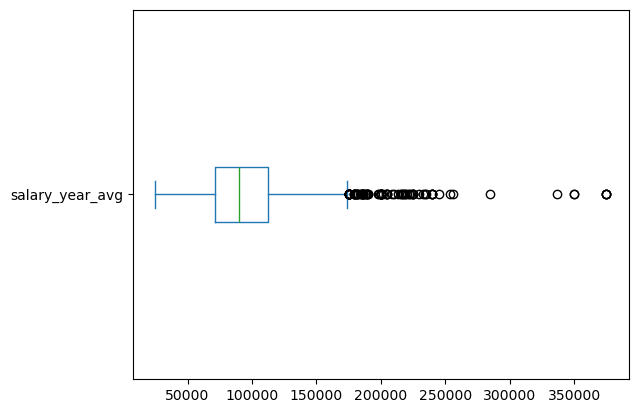

In [6]:
df_da_us['salary_year_avg'].plot(kind= 'box', vert = False)

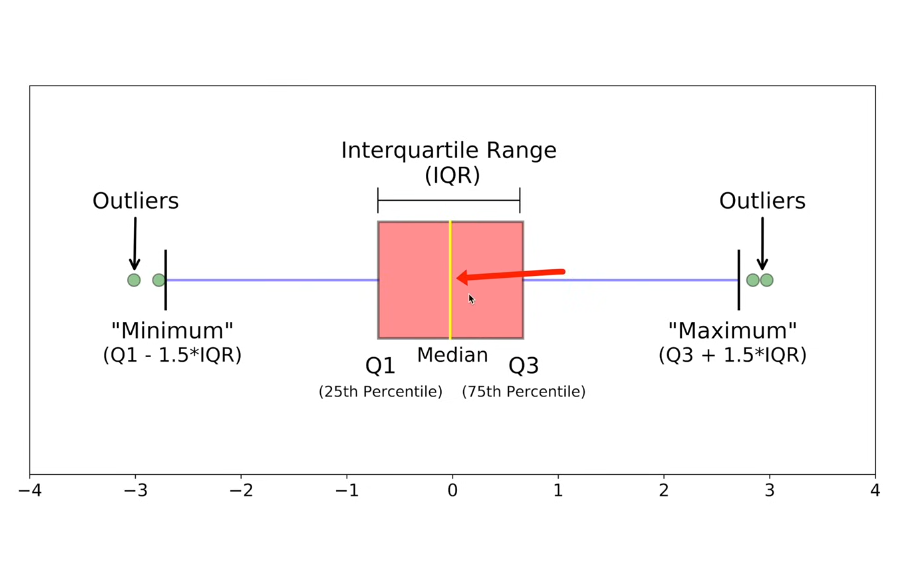

C:\Users\tom-i\AppData\Local\Temp\ipykernel_16168\1307158368.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


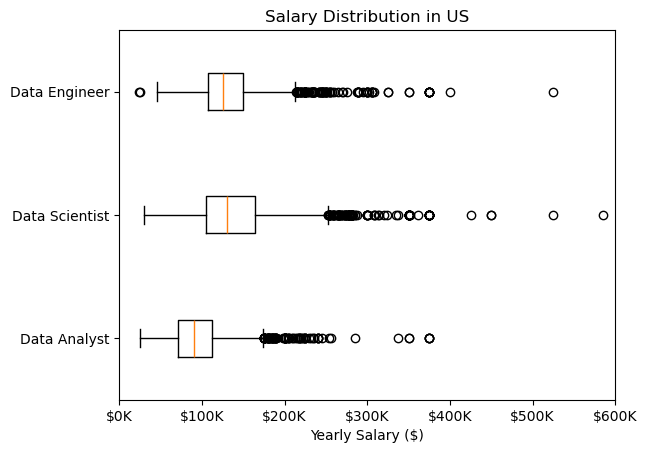

In [29]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_us = df_us.dropna(subset=['salary_year_avg'])

job_list = [df_us[df_us['job_title_short'] == job_titles]['salary_year_avg'] for job_titles in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in US')
plt.xlabel('Yearly Salary ($)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

In [11]:
df_us['job_title_short'].value_counts()

job_title_short
Data Analyst      67816
Data Scientist    58830
Data Engineer     35080
Name: count, dtype: int64